# InterviewIQ: Answer Quality Classification

### Final Machine Learning Notebook

This project classifies interview responses into **Weak**, **Average**, or **Strong**. The model uses TF-IDF text features and answer length with Logistic Regression.

> **Important:** This is a small curated starter dataset for demonstrating the full ML workflow. Its accuracy is a demonstration result, not a final research claim.

## 1. Import libraries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'weak': '#ef6a78', 'average': '#f6b44c', 'strong': '#48bd8b'}

## 2. Load and inspect the dataset

In [2]:
DATASET_PATH = Path('data/training_answers.csv')
data = pd.read_csv(DATASET_PATH)
data['word_count'] = data['answer'].str.split().str.len()

print(f'Dataset path: {DATASET_PATH.resolve()}')
print(f'Total labelled answers: {len(data)}')
print(f'Roles included: {data["role"].nunique()}')
data.head()

Dataset path: C:\Users\Asus\OneDrive\Desktop\InterviewIQ\data\training_answers.csv
Total labelled answers: 45
Roles included: 3


,role,topic,answer,label,word_count
0,Software Developer,OOP,OOP is a programming style.,weak,5
1,Software Developer,Python,A tuple and list are different things.,weak,7
2,Software Developer,Debugging,I will try again until the program works.,weak,8
3,Software Developer,API,API is used in software.,weak,5
4,Software Developer,Security,Security is important for websites.,weak,5


## 3. Dataset visualisation
The first chart shows how many examples belong to each quality label. The second chart explains why answer length is included as a transparent feature.

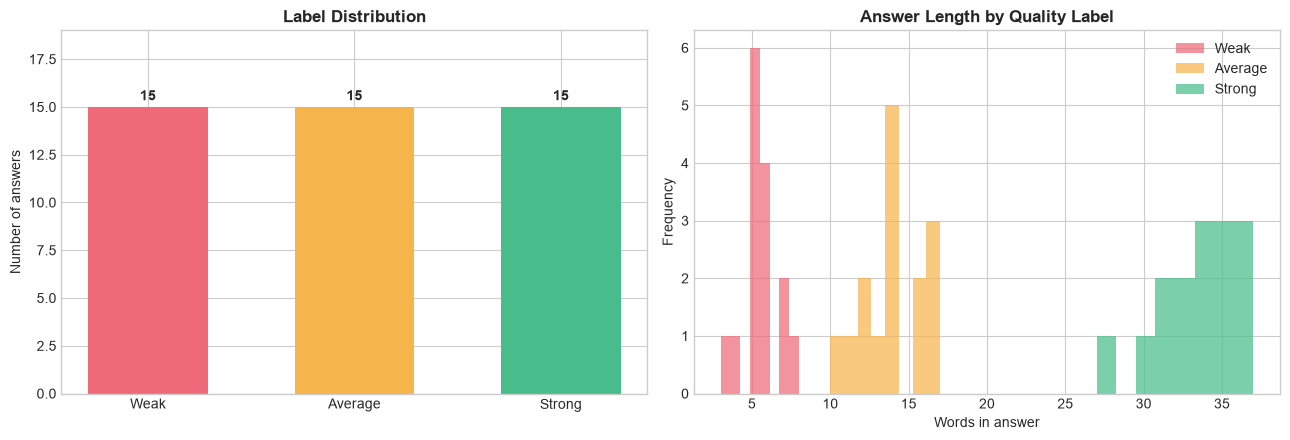

In [3]:
label_order = ['weak', 'average', 'strong']
label_counts = data['label'].value_counts().reindex(label_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bars = axes[0].bar(label_counts.index.str.title(), label_counts.values, color=[COLORS[x] for x in label_order], width=0.58)
axes[0].set_title('Label Distribution', fontweight='bold')
axes[0].set_ylabel('Number of answers')
axes[0].set_ylim(0, max(label_counts.values) + 4)
for bar, value in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, value + .35, str(value), ha='center', fontweight='bold')

for label in label_order:
    values = data.loc[data['label'] == label, 'word_count']
    axes[1].hist(values, bins=8, alpha=.72, label=label.title(), color=COLORS[label])
axes[1].set_title('Answer Length by Quality Label', fontweight='bold')
axes[1].set_xlabel('Words in answer')
axes[1].set_ylabel('Frequency')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Create train and test sets
70% of the data is used to train the model. The remaining 30% is unseen test data used only for evaluation.

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    data['answer'], data['label'], test_size=0.30, random_state=42, stratify=data['label']
)
print(f'Training samples: {len(x_train)} ({len(x_train) / len(data):.0%})')
print(f'Test samples:     {len(x_test)} ({len(x_test) / len(data):.0%})')

Training samples: 31 (69%)
Test samples:     14 (31%)


## 5. Build and train the classifier
- **TF-IDF** converts meaningful words and phrases into numerical features.
- **Answer length** is a simple explainable feature: stronger answers in this starter dataset are usually more detailed.
- **Logistic Regression** is fast, lightweight and suitable for a beginner-friendly baseline.

In [5]:
def answer_length(texts):
    """Return one transparent numeric feature: the number of words."""
    return np.array([[len(str(text).split())] for text in texts])

model = Pipeline([
    ('features', FeatureUnion([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english')),
        ('answer_length', Pipeline([
            ('count_words', FunctionTransformer(answer_length, validate=False)),
            ('scale', StandardScaler()),
        ])),
    ])),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])

model.fit(x_train, y_train)
print('Model training completed successfully.')

Model training completed successfully.


## 6. Final evaluation and confusion matrix

FINAL TEST RESULT
Test accuracy: 100.00%
Test samples:  14

Classification Report:

              precision    recall  f1-score   support

        weak       1.00      1.00      1.00         5
     average       1.00      1.00      1.00         4
      strong       1.00      1.00      1.00         5

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



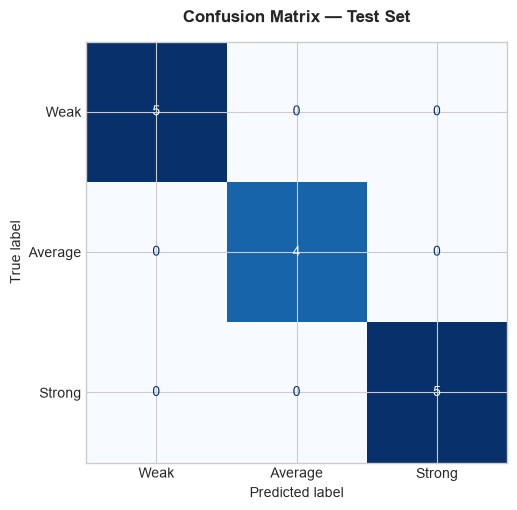

In [6]:
predictions = model.predict(x_test)
accuracy = accuracy_score(y_test, predictions)

print('=' * 48)
print('FINAL TEST RESULT')
print('=' * 48)
print(f'Test accuracy: {accuracy * 100:.2f}%')
print(f'Test samples:  {len(y_test)}')
print('\nClassification Report:\n')
print(classification_report(y_test, predictions, labels=label_order, zero_division=0))

fig, ax = plt.subplots(figsize=(6.2, 5.2))
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions, labels=label_order, display_labels=['Weak', 'Average', 'Strong'],
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title('Confusion Matrix — Test Set', fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

## 7. Predict a new interview answer
Edit `new_answer` and run the cell to classify your own answer.

In [7]:
new_answer = '''An API is a contract that lets a browser and a backend service communicate. The client sends an HTTP request to an endpoint and receives a structured response, often JSON.'''
prediction = model.predict([new_answer])[0]
probabilities = dict(zip(model.classes_, model.predict_proba([new_answer])[0].round(3)))

print('Predicted answer quality:', prediction.title())
print('Class probabilities:', probabilities)

Predicted answer quality: Strong
Class probabilities: {'average': np.float64(0.201), 'strong': np.float64(0.787), 'weak': np.float64(0.012)}


## 8. Final conclusion for viva

**Project result:** The model was trained on 45 labelled interview answers and evaluated using a fixed 70/30 train-test split. The notebook reports its test accuracy and confusion matrix above.

**How to explain it:** ‘I used a supervised learning baseline. TF-IDF converts answer text into features, word count represents answer detail, and Logistic Regression predicts weak, average or strong quality. I kept unseen test data separate to calculate accuracy. Since the dataset is small and curated, I would collect more real, manually labelled answers before claiming final real-world performance.’